# Getting started with the Tennessee Eastman Process

The Tennessee Eastman Process is a simulated chemical plant published by Downs and Vogel
in 1993 as an open challenge problem: a realistic, open-ended, badly behaved plant that
control and monitoring researchers could all work on and compare results for. It has four
reactions producing two liquid products from four gaseous reactants, five major unit
operations (reactor, condenser, vapour/liquid separator, recycle compressor and product
stripper), 41 measurements, 12 manipulated variables and 20 disturbances that can be
switched on. Thirty years later it is still the standard benchmark for fault detection,
which is why this notebook exists.

`tepsim` is a pure-Rust port of the original Fortran, wrapped as a Python package with no
C dependencies. It is a port of the model, not a reimplementation from a paper: every
function carries the line range of `teprob.f` it came from, and the port is checked
against the Fortran through a ten-tier validation ladder. Given the same `exp` and `pow`,
a 48-hour closed-loop run of 172,800 integrator steps is bit-identical in all 41
measurements and all 12 manipulated variables.

This notebook is for someone who has never seen the process. It runs the plant, looks at
what comes out, injects a fault, reads the ground truth back, shows that a run is
reproducible from its description, and finishes with what happens when the plant trips.

*References for this notebook are listed at the bottom.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tepsim as tep

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 3.2),
                     "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

print("tepsim", tep.__version__)
print("measurements XMEAS(1..%d), manipulated XMV(1..%d), %d channels in all"
      % (tep.MEASUREMENTS, tep.MANIPULATED, tep.CHANNELS))
print("disturbances IDV(1..%d)" % tep.DISTURBANCES)
print("default seed %r, default step %.6g h (%.1f s), one sample every %d steps"
      % (tep.DEFAULT_SEED, tep.DEFAULT_STEP_HOURS, tep.DEFAULT_STEP_HOURS * 3600,
         tep.DEFAULT_SAMPLE_EVERY))

tepsim 0.0.0
measurements XMEAS(1..41), manipulated XMV(1..12), 53 channels in all
disturbances IDV(1..20)
default seed 4651207995.0, default step 0.000277778 h (1.0 s), one sample every 180 steps


## Scenario, Simulation, Run

The whole API is three objects. A `Scenario` says what to simulate and is immutable and
cheap to copy. A `Simulation` holds a plant, a controller stack and an integrator state.
A `Run` is what comes out: the samples as arrays, the ground truth, and how the run ended.

The separation matters more than it looks. A run in this port is a pure function of its
scenario: there is no clock, no global state and no randomness outside the seeded
generator. That is what makes a recorded dataset reproducible from its description
rather than from a file, and it is why the scenario is a value you can print, hash and
send to someone else.

The default is 48 hours of the fault-free plant under closed-loop control, sampled every
180 seconds, which is the cadence the published Tennessee Eastman datasets use.

In [2]:
scenario = tep.Scenario.baseline(hours=48)
print(scenario)

run = tep.Simulation(scenario).run()
print(run)
print()
print("outcome:", run.outcome)
print("samples:", len(run))
print("matrix: ", run.to_numpy().shape, run.to_numpy().dtype)
print("hours:   %.2f to %.2f" % (run.hours[0], run.hours[-1]))

Scenario(seed=4651207995.0, hours=48.0, step_hours=0.0002777777777777778, sample_every=180, faults=(), controlled=True, driver_forces_idv12=False, trip_ends_the_run=True)


<tepsim.Run 960 samples x 53 channels, 48.0 h, completed>

outcome: completed
samples: 960
matrix:  (960, 53) float64
hours:   0.05 to 48.00


## The 53 channels

`to_numpy()` gives one `(n_samples, 53)` array: `XMEAS(1)` through `XMEAS(41)` first, then
`XMV(1)` through `XMV(12)`. The 41 measurements are what an operator sees, and they are
not all sampled at the same rate in the real problem: measurements 1 to 22 are continuous
process variables, 23 to 36 come from the reactor feed and purge gas chromatographs on a
six-minute analysis with a delay, and 37 to 41 are product composition on a fifteen-minute
analysis. The port reproduces those sampling delays, so the composition channels come out
as staircases rather than smooth curves.

Every array a `Run` hands out is a read-only view into one buffer, filled once when the
run finishes. Call `.copy()` if you want something writable.

In [3]:
names = tep.channel_names()
for i in range(0, 53, 3):
    print("  ".join("%2d %-28s" % (j + 1, names[j]) for j in range(i, min(i + 3, 53))))

 1 XMEAS_1_A_feed                 2 XMEAS_2_D_feed                 3 XMEAS_3_E_feed              
 4 XMEAS_4_total_feed             5 XMEAS_5_recycle_flow           6 XMEAS_6_reactor_feed_rate   
 7 XMEAS_7_reactor_pressure       8 XMEAS_8_reactor_level          9 XMEAS_9_reactor_temperature 
10 XMEAS_10_purge_rate           11 XMEAS_11_separator_temperature  12 XMEAS_12_separator_level    
13 XMEAS_13_separator_pressure   14 XMEAS_14_separator_underflow  15 XMEAS_15_stripper_level     
16 XMEAS_16_stripper_pressure    17 XMEAS_17_stripper_underflow   18 XMEAS_18_stripper_temperature
19 XMEAS_19_stripper_steam_flow  20 XMEAS_20_compressor_work      21 XMEAS_21_reactor_cw_outlet  
22 XMEAS_22_condenser_cw_outlet  23 XMEAS_23_feed_A               24 XMEAS_24_feed_B             
25 XMEAS_25_feed_C               26 XMEAS_26_feed_D               27 XMEAS_27_feed_E             
28 XMEAS_28_feed_F               29 XMEAS_29_purge_A              30 XMEAS_30_purge_B            
31 XMEAS_31_purge

### How a row is timed

Two hours is 7200 integrator steps at one step per simulated second, and a row is written
every 180 of them, which is the three-minute spacing the published `d00` through `d21`
files use. Two hours is therefore forty rows and 48 hours is 960.

The first row is at 0.0497 hours rather than at 0.05, and that is not an off-by-one. Its
step is 180 and its time is the instant step 180 *began*, which is 179 seconds. The clock
is advanced at the end of a step, after the row has been written, because that is the
order `temain_mod.f` writes in: a row carrying the post-step time would be labelled with a
clock the plant had not reached when it was measured.

In [4]:
short = tep.Simulation(tep.Scenario.baseline(hours=2)).run()
print("%d integrator steps, one row every %d of them, so %d rows"
      % (short.scenario.steps, short.scenario.sample_every, len(short)))
print()
print("row    step     hours    seconds")
for i in (0, 1, len(short) - 1):
    print("%3d   %5d   %7.4f   %8.1f"
          % (i, short.steps[i], short.hours[i], short.hours[i] * 3600))

7200 integrator steps, one row every 180 of them, so 40 rows

row    step     hours    seconds
  0     180    0.0497      179.0
  1     360    0.0997      359.0
 39    7200    1.9997     7199.0


## What normal operation looks like

Under the base case control scheme the plant holds itself at a setpoint. The measurements
below wander, but they wander inside a band: the reactor pressure sits near 2705 kPa, the
reactor temperature is pinned within a few hundredths of a degree of 120.4 C, and the
levels drift by a few percent. That drift is not numerical noise. Several feed conditions
are driven by slow random walks that are always running, fault or no fault, so a
fault-free 48-hour record is a stochastic process and not a constant.

The manipulated variables in the bottom row are the other half of the picture: the plant
looks calm because the controllers are working. Ricker's 1996 decentralised control study
is the standard reference for why holding this particular plant is hard.

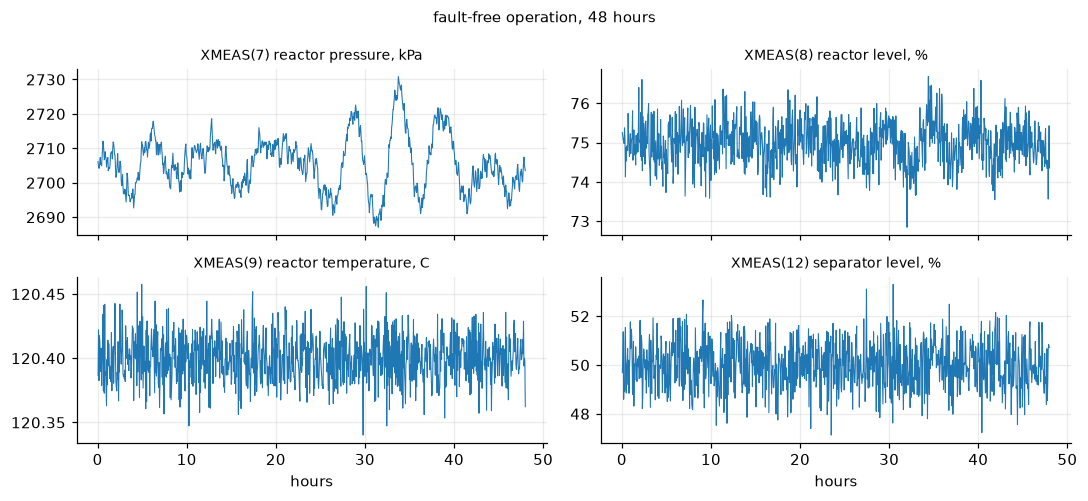

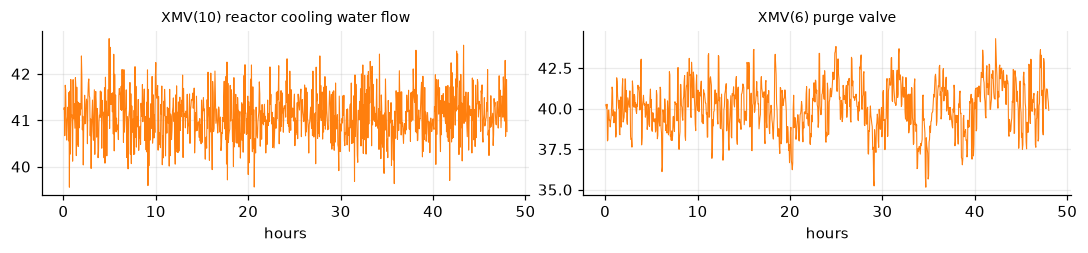

reactor pressure    mean  2705.64  sd  7.797  range 2687.07 to 2730.87
reactor temperature mean 120.3998  sd 0.0181


In [5]:
show = [(7, "XMEAS(7) reactor pressure, kPa"),
        (8, "XMEAS(8) reactor level, %"),
        (9, "XMEAS(9) reactor temperature, C"),
        (12, "XMEAS(12) separator level, %")]
fig, axes = plt.subplots(2, 2, figsize=(10, 4.6), sharex=True)
for ax, (n, label) in zip(axes.ravel(), show):
    ax.plot(run.hours, run.measurement(n), lw=0.7)
    ax.set_title(label, fontsize=9)
for ax in axes[1]:
    ax.set_xlabel("hours")
fig.suptitle("fault-free operation, 48 hours", fontsize=10)
fig.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(10, 2.4), sharex=True)
for ax, n, label in [(axes[0], 10, "XMV(10) reactor cooling water flow"),
                     (axes[1], 6, "XMV(6) purge valve")]:
    ax.plot(run.hours, run.manipulated(n), lw=0.7, color="tab:orange")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("hours")
fig.tight_layout()
plt.show()

print("reactor pressure    mean %8.2f  sd %6.3f  range %.2f to %.2f"
      % (run.measurement(7).mean(), run.measurement(7).std(),
         run.measurement(7).min(), run.measurement(7).max()))
print("reactor temperature mean %8.4f  sd %6.4f" % (run.measurement(9).mean(),
                                                    run.measurement(9).std()))

Here is the sampling-delay effect, which surprises people the first time they plot a
composition channel. `XMEAS(1)` is a flow meter and updates every sample. `XMEAS(23)` is
component A in the reactor feed, from a gas chromatograph, and `XMEAS(40)` is component G
in the product, from a slower one. They are step functions.

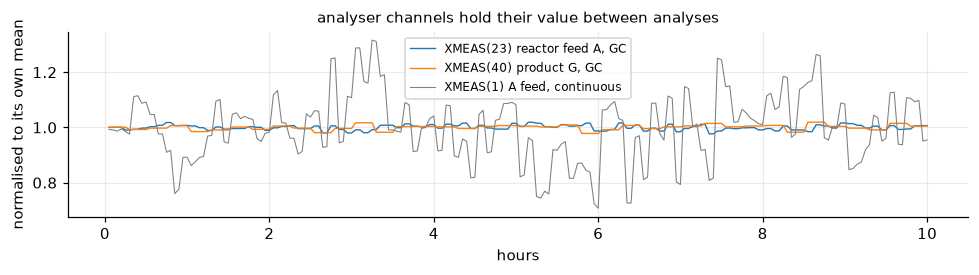

In [6]:
fig, ax = plt.subplots(figsize=(9, 2.6))
for n, label in [(23, "XMEAS(23) reactor feed A, GC"),
                 (40, "XMEAS(40) product G, GC")]:
    series = run.measurement(n)
    ax.plot(run.hours[:200], series[:200] / series[:200].mean(), lw=0.9, label=label)
ax.plot(run.hours[:200], run.measurement(1)[:200] / run.measurement(1)[:200].mean(),
        lw=0.7, color="0.5", label="XMEAS(1) A feed, continuous")
ax.set_xlabel("hours")
ax.set_ylabel("normalised to its own mean")
ax.legend(fontsize=8)
ax.set_title("analyser channels hold their value between analyses", fontsize=10)
fig.tight_layout()
plt.show()

## The twenty faults

The original header calls five of the disturbances "Unknown", which has been copied into
every derived dataset and every paper since. This port read the Fortran instead and says
what each one does, along with how it enters the model. There are three shapes:

A **step** fault changes a feed condition the moment it is switched on and holds it. A
**random** fault enables one or more random walk channels, which then wander on their own.
A **sticking** fault touches no equation at all: it widens the dead band a valve command
has to cross before the valve follows. That last one matters for interpretation, because
in an open-loop run, where the command never moves, a sticking fault does nothing at all.

In [7]:
print("IDV  shape     published description")
print("                 what it actually does")
for f in tep.faults():
    print("%3d  %-9s %s" % (f.index, f.shape, f.published))
    print("                 %s" % f.effect)

IDV  shape     published description
                 what it actually does
  1  step      A/C Feed Ratio, B Composition Constant (Stream 4)
                 steps the mixed feed's A fraction down by 0.03
  2  step      B Composition, A/C Ratio Constant (Stream 4)
                 steps B up by 0.005 and A down by 2.43719e-3, on two lines
  3  step      D Feed Temperature (Stream 2)
                 steps the D feed temperature up by 5 C
  4  step      Reactor Cooling Water Inlet Temperature
                 steps the reactor coolant inlet up by 5 C
  5  step      Condenser Cooling Water Inlet Temperature
                 steps the condenser coolant inlet up by 5 C
  6  step      A Feed Loss (Stream 1)
                 shuts the A feed off entirely, not partially
  7  step      C Header Pressure Loss - Reduced Availability (Stream 4)
                 reduces the mixed feed's capacity by 20%
  8  random    A, B, C Feed Composition (Stream 4)
                 enables two walk channels, o

## Injecting a fault

`Scenario.fault(n)` switches `IDV(n)` on for the whole run. That is what the original
does, and it is the right thing when you want a faulted record. It is not the right thing
when you want to see the fault *arrive*, and arrival is what a detector is judged on.

For that this port lets a scenario carry a schedule, written into the scenario's canonical
text form. The helper below is three lines and notebook 4 covers the format properly. The
important part is that `IDV(4)` is off for the first eight hours and on afterwards, which
is the layout the published Tennessee Eastman test sets use.

`IDV(4)` is a step of 5 C in the reactor cooling water inlet temperature. Watch what
happens: the reactor temperature, `XMEAS(9)`, barely moves. The controller sees the
temperature start to rise and opens the cooling water valve, `XMV(10)`, until it stops
rising. The disturbance is absorbed almost entirely into the manipulated variable. This is
the single most important thing to understand about fault detection on a controlled plant:
a good controller hides the fault from the measurements that a naive monitor watches.

tepsim.scenario.v1;seed=1234567891;hours=24;step=2.777777777777778e-4;every=180;faults=;controlled=1;idv12=0;trip=1;continuous=0;integrator=euler;events=8:start:4


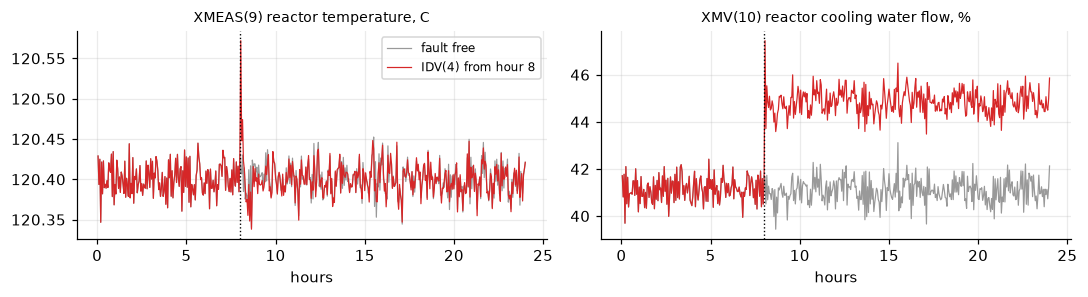

after hour 10, fault free vs faulted
  XMEAS(9)  120.399542  vs  120.399514   (difference -0.000028 C)
            fault-free sd is 0.018728 C, so the shift is 0.002 of one sd
  XMV(10)   41.103  vs  44.868   (difference +3.766 % of valve travel)


In [8]:
def starting_at(fault, hour, base):
    "The scenario `base`, with IDV(fault) switching on at `hour`."
    return tep.Scenario.from_text(
        base.to_text().replace("events=", "events=%g:start:%d" % (hour, fault)))


healthy = tep.Scenario.baseline(hours=24, seed=1_234_567_891.0)
faulted = starting_at(4, 8.0, healthy)
print(faulted.to_text())

a = tep.Simulation(healthy).run()
b = tep.Simulation(faulted).run()

fig, axes = plt.subplots(1, 2, figsize=(10, 2.8), sharex=True)
for ax, series, label in [
        (axes[0], lambda r: r.measurement(9), "XMEAS(9) reactor temperature, C"),
        (axes[1], lambda r: r.manipulated(10), "XMV(10) reactor cooling water flow, %")]:
    ax.plot(a.hours, series(a), lw=0.8, color="0.6", label="fault free")
    ax.plot(b.hours, series(b), lw=0.8, color="tab:red", label="IDV(4) from hour 8")
    ax.axvline(8.0, color="k", ls=":", lw=0.9)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("hours")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

after = b.hours >= 10.0
shift = b.measurement(9)[after].mean() - a.measurement(9)[after].mean()
noise = a.measurement(9)[after].std()
print("after hour 10, fault free vs faulted")
print("  XMEAS(9)  %.6f  vs  %.6f   (difference %+.6f C)"
      % (a.measurement(9)[after].mean(), b.measurement(9)[after].mean(), shift))
print("            fault-free sd is %.6f C, so the shift is %.3f of one sd"
      % (noise, abs(shift) / noise))
print("  XMV(10)   %.3f  vs  %.3f   (difference %+.3f %% of valve travel)"
      % (a.manipulated(10)[after].mean(), b.manipulated(10)[after].mean(),
         b.manipulated(10)[after].mean() - a.manipulated(10)[after].mean()))

## Ground truth

The original records nothing about what was wrong with the plant: a published dataset is a
matrix and a filename, and every detection-delay figure in the literature is computed
against whatever onset the author assumed. This port carries the labels along with the
data.

`labels()` returns two `(n_samples, 20)` arrays indexed by `IDV(n) - 1`. `active` is
whether that disturbance was on at that sample. `since_onset` is how many hours it had
been on, and NaN where it never was. Note that `since_onset` is not simply the time since
the run began: with a schedule, one disturbance can arrive later than another.

In [9]:
labels = b.labels()
print("active     ", labels["active"].shape, labels["active"].dtype)
print("since_onset", labels["since_onset"].shape, labels["since_onset"].dtype)
print()
print("  hours   any fault   IDV(4) active   hours since IDV(4) onset")
for hour in (0.0, 7.0, 8.0, 9.0, 16.0, 23.0):
    i = int(np.searchsorted(b.hours, hour))
    since = labels["since_onset"][i, 3]
    print("  %5.2f      %-5s          %-5s          %s"
          % (b.hours[i], labels["active"][i].any(), labels["active"][i, 3],
             "never" if np.isnan(since) else "%.2f" % since))

active      (480, 20) bool
since_onset (480, 20) float64

  hours   any fault   IDV(4) active   hours since IDV(4) onset
   0.05      False          False          never
   7.05      False          False          never
   8.05      True           True           0.05
   9.05      True           True           1.05
  16.05      True           True           8.05
  23.05      True           True           15.05


Labels are what make a detection experiment scriptable rather than hand-annotated. The
onset index, for example, is a one-liner rather than a constant someone has to remember:

In [10]:
onset = int(np.argmax(labels["active"][:, 3]))
print("IDV(4) first active at sample %d, hour %.2f" % (onset, b.hours[onset]))
print("post-onset samples:", len(b) - onset)

IDV(4) first active at sample 160, hour 8.05
post-onset samples: 320


### The disturbance you did not ask for

`temain_mod.f:366-368` switches `IDV(12)` on eight hours into every run, whatever the
caller asked for, so a record nominally labelled `IDV(4)` really carries `IDV(4)` and
`IDV(12)` together after hour eight, and both of them act on cooling water.

This port does not do that by default. Tier 7 established that the published files were
generated with that line replaced rather than kept: every `dNN_te` file except `d12_te`
sits at the nominal operating point straight across row 160, which is hour eight. Pass
`driver_forces_idv12=True` to reproduce the driver. The labels make the difference visible
either way, which is the whole point of recording ground truth rather than assuming it.

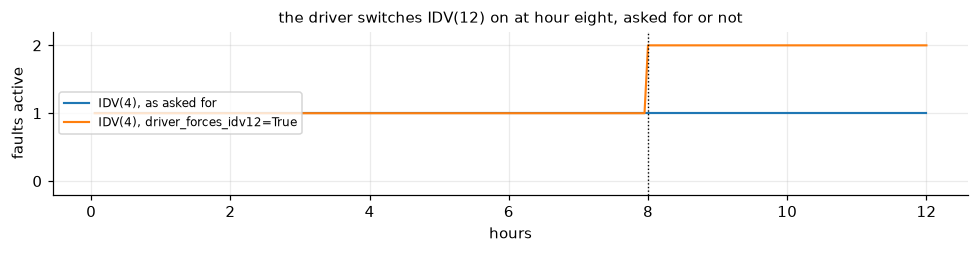

as asked for   active at 12 h: [4]
driver         active at 12 h: [4, 12]


In [11]:
asked_for = tep.Simulation(tep.Scenario.fault(4, hours=12)).run()
driver = tep.Simulation(
    tep.Scenario.fault(4, hours=12, driver_forces_idv12=True)).run()

fig, ax = plt.subplots(figsize=(9, 2.4))
for r, label in [(asked_for, "IDV(4), as asked for"),
                 (driver, "IDV(4), driver_forces_idv12=True")]:
    ax.plot(r.hours, r.labels()["active"].sum(axis=1), lw=1.4, label=label)
ax.axvline(8.0, color="k", ls=":", lw=0.9)
ax.set_xlabel("hours")
ax.set_ylabel("faults active")
ax.set_yticks([0, 1, 2])
ax.set_ylim(-0.2, 2.2)
ax.legend(fontsize=8, loc="center left")
ax.set_title("the driver switches IDV(12) on at hour eight, asked for or not",
             fontsize=10)
fig.tight_layout()
plt.show()

for r, label in [(asked_for, "as asked for"), (driver, "driver      ")]:
    live = 1 + np.flatnonzero(r.labels()["active"][-1])
    print("%s   active at 12 h: %s" % (label, live.tolist()))

## Reproducibility

A run is a pure function of its scenario, and the notebook can check that claim rather
than take it on faith. Running the same scenario twice gives bit-identical output, not
merely close output. Changing the seed changes the realisation of the random walks and
the measurement noise while leaving the plant and the controllers alone.

Each scenario also carries a `digest`, sixteen hex characters over everything the run
depends on, and a canonical one-line text form that parses back to an equal scenario. A
dataset labelled with its digest and shipped with its scenario text can be *checked*
rather than believed.

In [12]:
first = tep.Simulation(healthy).run().to_numpy()
again = tep.Simulation(healthy).run().to_numpy()
print("same scenario twice, bit-identical:", np.array_equal(first, again))
print("max absolute difference:", np.abs(first - again).max())

other = tep.Simulation(healthy.with_seed(4_651_207_995.0)).run().to_numpy()
print()
print("different seed, still bit-identical:", np.array_equal(first, other))
print("max absolute difference: %.4g" % np.abs(first - other).max())
print("reactor pressure mean %.3f vs %.3f" % (first[:, 6].mean(), other[:, 6].mean()))

print()
print("digest, fault free  :", healthy.digest)
print("digest, IDV(4) at 8 :", faulted.digest)
print("text round-trips    :", tep.Scenario.from_text(faulted.to_text()) == faulted)

same scenario twice, bit-identical: True
max absolute difference: 0.0



different seed, still bit-identical: False
max absolute difference: 158.3
reactor pressure mean 2705.870 vs 2706.259

digest, fault free  : df8b6d3ef4e7243e
digest, IDV(4) at 8 : 4bfe7feb9289562a
text round-trips    : True


## What a trip looks like

The plant has eight shutdown conditions, on reactor pressure, reactor level, reactor
temperature, separator level and stripper level. Cross one and the simulation is over:
this is a chemical plant, and the interesting failures are not gentle.

`IDV(6)` is a total loss of the A feed. The controllers cannot make product without A, the
reactor pressure climbs, and at 3000 kPa the plant trips. By default a trip ends the run,
so the `Run` is short and reports why. That is a result, not an error: `run()` never raises
for a plant that misbehaves, because a run that ended early is data and throwing it away
would hide the difference between a port that trips where the original does and one that
does not.

<tepsim.Run 276 samples x 53 channels, 48.0 h, tripped at 13.846 h (reactor pressure high)>

outcome        : tripped
tripped at step: 49848
tripped at hour: 13.846
cause          : reactor pressure high
samples kept: 276 of the 960 a completed run would have


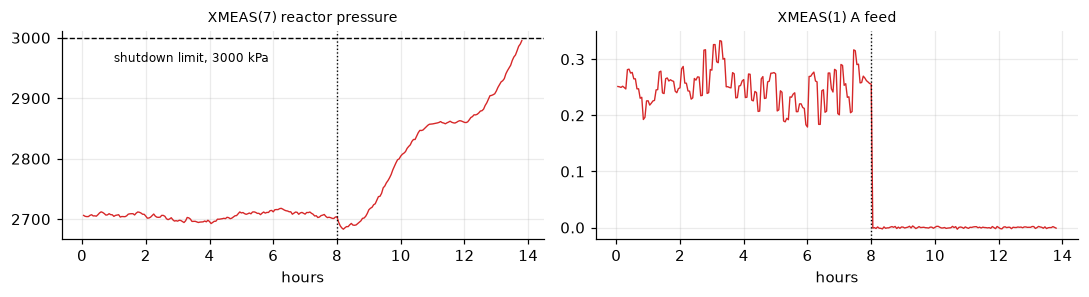

In [13]:
lost_feed = tep.Simulation(starting_at(6, 8.0, tep.Scenario.baseline(hours=48))).run()
print(lost_feed)
print()
print("outcome        :", lost_feed.outcome)
print("tripped at step:", lost_feed.tripped_at)
print("tripped at hour: %.3f" % lost_feed.tripped_hours)
print("cause          :", lost_feed.trip_cause)
print("samples kept: %d of the %d a completed run would have"
      % (len(lost_feed), lost_feed.scenario.samples))

fig, axes = plt.subplots(1, 2, figsize=(10, 2.8), sharex=True)
axes[0].plot(lost_feed.hours, lost_feed.measurement(7), lw=0.9, color="tab:red")
axes[0].axhline(3000.0, color="k", ls="--", lw=0.9)
axes[0].annotate("shutdown limit, 3000 kPa", (1, 2960), fontsize=8)
axes[0].set_title("XMEAS(7) reactor pressure", fontsize=9)
axes[1].plot(lost_feed.hours, lost_feed.measurement(1), lw=0.9, color="tab:red")
axes[1].set_title("XMEAS(1) A feed", fontsize=9)
for ax in axes:
    ax.axvline(8.0, color="k", ls=":", lw=0.9)
    ax.set_xlabel("hours")
fig.tight_layout()
plt.show()

Every fault is not equally violent. Most of the twenty complete a 48-hour run without ever
approaching a limit, so a quick survey is worth doing before designing an experiment
around them. Note that `run()` releases the GIL for the whole integration, so an ensemble
is a thread pool and nothing has to be pickled.

In [14]:
from concurrent.futures import ThreadPoolExecutor

sims = [tep.Simulation(tep.Scenario.fault(n, hours=48)) for n in range(1, 21)]
with ThreadPoolExecutor() as pool:
    survey = list(pool.map(tep.Simulation.run, sims))

print("IDV  outcome     samples  ended at   cause")
for n, r in zip(range(1, 21), survey):
    print("%3d  %-10s  %6d  %7s   %s"
          % (n, r.outcome, len(r),
             "-" if r.tripped_hours is None else "%.2f h" % r.tripped_hours,
             r.trip_cause or ""))

IDV  outcome     samples  ended at   cause
  1  completed      960        -   
  2  completed      960        -   
  3  completed      960        -   
  4  completed      960        -   
  5  completed      960        -   
  6  tripped        116   5.84 h   reactor pressure high
  7  completed      960        -   
  8  completed      960        -   
  9  completed      960        -   
 10  completed      960        -   
 11  completed      960        -   
 12  completed      960        -   
 13  completed      960        -   
 14  completed      960        -   
 15  completed      960        -   
 16  completed      960        -   
 17  completed      960        -   
 18  completed      960        -   
 19  completed      960        -   
 20  completed      960        -   


Only `IDV(6)` trips at this seed. That is a property of the seed and not of the fault:
several of the random-walk and spiking faults trip on some realisations and not on others,
which notebook 3 measures over ten seeds.

## Where to go next

Notebook 2 builds the standard PCA monitoring scheme on this plant and measures what it is
worth. Notebook 3 reproduces the best known result in the Tennessee Eastman literature,
that three of the twenty faults are essentially undetectable by these methods. Notebook 4
covers what this port can express that the original cannot: schedules, composed faults,
continuous fault magnitudes and a choice of integrator.

## References

- J. J. Downs and E. F. Vogel, "A plant-wide industrial process control problem",
  *Computers & Chemical Engineering* **17**(3), 245-255 (1993).
  doi:10.1016/0098-1354(93)80018-I
- N. L. Ricker, "Decentralized control of the Tennessee Eastman challenge process",
  *Journal of Process Control* **6**(4), 205-221 (1996).
  doi:10.1016/0959-1524(96)00031-5
- A. Bathelt, N. L. Ricker and M. Jelali, "Revision of the Tennessee Eastman process
  model", *IFAC-PapersOnLine* **48**(8), 309-314 (2015).
  doi:10.1016/j.ifacol.2015.08.199